# Ex11 — Shaping light to measure a nanobead's size and index

A bead's radius and refractive index both set how strongly it scatters. For beads below about
150 nm they are nearly the same parameter: in the dipole limit the scattered field depends on them
only through the polarisability α ∝ r³(m² − 1)/(m² + 2). Measuring them apart relies on weak
higher-order effects (the magnetic dipole and electric quadrupole, and the phase of α), and
each interferometer's reconstruction keeps only part of what its camera recorded.

This example asks how much light shaping can do about it, in the spirit of PSF design for 3D
localisation (DeepSTORM3D): minimise the Cramér–Rao bound on radius *and* index, through the
reconstruction each instrument uses (ADR-44), over the reference and the illumination. A gain
must not depend on where the bead lies in the field of view, so the designs are judged across
positions. Independent readouts add their Fisher information (`bound_a + bound_b`), so a
modulator alternating between two states is one design.

The sections:

1. the microscopes, at a common dose;
2. the near-degeneracy of radius and index, per bead size and reconstruction;
3. the reference: contrast is not information;
4. a pupil modulator that focuses onto the bead, and why that is not characterisation;
5. uniform illumination at a designed angle, which cannot depend on position;
6. two alternating states.

**Level** L3 (Chains, reconstructions, `gx.crlb` with `reconstruction=`) · **Prerequisites**
Ex10 · **Runtime** about 4 min on a GPU. `SMOKE` (set by the test suite) shrinks the frames and
iteration counts. The scattering is scalar (P = 1): the designs below reach angles where
polarisation matters, so read the numbers as comparisons, not predictions, until the vector
model (P = 2) lands.

In [1]:
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

import gradix as gx

SMOKE = os.environ.get("GRADIX_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() and not SMOKE else "cpu"
F64 = torch.float64
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 9})
COLORS = {"in-line": "#1f77b4", "off-axis": "#ff7f0e", "iSCAT": "#2ca02c", "QWLSI": "#9467bd"}


def to_numpy(t: torch.Tensor) -> np.ndarray:
    """Return a CPU NumPy copy of a tensor, for plotting."""
    return t.detach().cpu().numpy()


def tensor(value: object) -> torch.Tensor:
    """Return a float64 tensor on the notebook's device."""
    return torch.as_tensor(value, dtype=F64, device=DEVICE)

## 1. Four microscopes at one dose

Every microscope gets 10⁶ photons/µm² per exposure at the sample, so they are compared at equal
dose. The camera has 65 nm pixels in the sample, shot noise and 2 e⁻ of read noise; read noise
matters where a design darkens the frame (an ideal shot-noise camera would credit nearly dark
pixels with unphysical information). `microscope(kind, light, beads)` builds each Chain:

- **in-line**: NA 0.8, focused 1.5 µm below the bead, so the reconstruction back-propagates by
  1.5 µm (in focus, a small transparent bead is almost invisible to in-line holography: its
  scattered field is in quadrature with the unscattered light);
- **off-axis**: a reference as bright as the illumination, tilted so that its fringes sit on the
  frame's DFT grid;
- **iSCAT**: the bead on a coverslip under epi light through an NA 1.4 oil objective; the
  glass–water interface reflects 0.45 % as the reference;
- **QWLSI**: a Hartmann grating 0.3 mm before the camera, fringes of 4 pixels.

The bound is taken on `beads.radius` and `beads.material`, one bead per image.

In [2]:
N = 24 if SMOKE else 48  # camera pixels per axis
STEPS = 2 if SMOKE else 60  # design iterations
WAVELENGTH, PIXEL, MAG, DOSE = 0.532, 6.5, 100.0, 1e6
pitch = PIXEL / MAG
camera = gx.Camera(
    pixel_size=PIXEL, shape=(N, N), noise=gx.noise.PoissonGaussian(read=2.0), unit="e"
)
WATER = gx.env.Homogeneous(1.33)
GLASS = gx.env.LayeredMedium(sample=1.33, coverslip=1.52, immersion=1.52)
KINDS = ("in-line", "off-axis", "iSCAT", "QWLSI")
WRT = ("beads.radius", "beads.material")
centre = N * pitch / 2


def beads(diameter: float, xy: torch.Tensor | None = None, on_glass: bool = False) -> gx.Spheres:
    """Return polystyrene beads, one per image at the positions xy [B, 2] (the centre if None)."""
    xy = tensor([[centre + 0.013, centre - 0.021]]) if xy is None else xy
    z = -diameter / 2 - 0.001 if on_glass else 0.0  # resting on the coverslip, or in focus
    b = xy.shape[0]
    position = torch.cat([xy, torch.full((b, 1), z, dtype=F64, device=DEVICE)], -1)
    return gx.Spheres(
        position=position[:, None, None],
        radius=tensor(diameter / 2).expand(b, 1, 1),
        material=tensor(1.59).expand(b, 1, 1),
    )


def plane_wave(
    kind: str, direction: torch.Tensor | None = None, dose: float = DOSE
) -> gx.light.PlaneWave:
    """Return the microscope's light: transmitted, or epi for iSCAT."""
    travel = -1 if kind == "iSCAT" else 1
    return gx.light.PlaneWave(
        tensor(WAVELENGTH), direction=direction, irradiance=tensor(dose), travel=travel
    )


cycles = round(0.31 * N)  # the reference's fringe periods per axis: beyond 3·NA, below Nyquist
tilt = math.asin(WAVELENGTH * cycles / (N * pitch) / MAG)


def microscope(kind: str, light: gx.Element, bead: gx.Spheres, dose: float = DOSE) -> gx.Chain:
    """Return the Chain of one microscope with a light and beads."""
    if kind == "iSCAT":
        imaging = gx.imaging.Coherent(
            gx.Objective(NA=1.4, magnification=MAG), camera, pupil_samples=64
        )
        return gx.Chain(
            light=light,
            scatterers={"beads": gx.interact.Mie(bead)},
            imaging=imaging,
            environment=GLASS,
        )
    focus = -1.5 if kind == "in-line" else 0.0
    imaging = gx.imaging.Coherent(gx.Objective(NA=0.8, magnification=MAG, focus=focus), camera)
    references, stages = {}, {}
    if kind == "off-axis":
        references = {"reference": gx.light.ReferenceBeam(tensor(dose), angle=tensor([tilt, tilt]))}
    if kind == "QWLSI":
        stages = {"grating": gx.optics.Grating(period=4 * PIXEL, distance=300.0)}
    return gx.Chain(
        light=light,
        scatterers={"beads": gx.interact.Mie(bead)},
        imaging=imaging,
        references=references,
        detection_optics=stages,
        environment=WATER,
    )


def reconstruction(kind: str, chain: gx.Chain) -> gx.recon.Reconstruction:
    """Return the reconstruction each microscope uses, calibrated on the Chain."""
    if kind == "in-line":
        return gx.recon.Inline.from_chain(chain, distance=1.5, normalize=True, pad=0)
    if kind == "off-axis":  # no division by the background: darkfield designs have none
        return gx.recon.OffAxis.from_chain(chain, normalize=False)
    if kind == "iSCAT":
        return gx.recon.ISCATContrast.from_chain(chain)
    return gx.recon.QWLSI.from_chain(chain)


def together(bounds: list[gx.CRLB]) -> gx.CRLB:
    """Return the bound of independent readouts, whose information adds (like sum(bounds))."""
    total = bounds[0]
    for bound in bounds[1:]:
        total = total + bound
    return total


def summary(bound: gx.CRLB) -> dict[str, float]:
    """Return a single bead's joint bounds, the radius bound with the index known, and 1 − ρ²."""
    info, cov = bound.fisher[0].double(), bound.covariance[0].double()
    rho = cov[0, 1] / torch.sqrt(cov[0, 0] * cov[1, 1])
    return {
        "radius": float(bound["beads.radius"].reshape(-1)[0]),
        "index": float(bound["beads.material"].reshape(-1)[0]),
        "radius alone": float(1.0 / torch.sqrt(info[0, 0])),
        "1-rho2": float(1.0 - rho * rho),
    }

## 2. Radius and index are nearly one parameter

For each bead size and microscope, the bound through the reconstruction, on radius and index
jointly, next to the radius bound when the index is known. The ratio between the two measures
the degeneracy: the joint bound exceeds the index-known one by 1/√(1 − ρ²), where ρ is the
correlation of the two estimates.

24 bounds in 10.5 s
in-line   100 nm bead: σ_r =   467.64 nm jointly,  2.812 nm with the index known; σ_n = 7.38
off-axis  100 nm bead: σ_r =   851.25 nm jointly,  4.790 nm with the index known; σ_n = 13.5
iSCAT     100 nm bead: σ_r =    92.40 nm jointly,  2.312 nm with the index known; σ_n = 1.28
QWLSI     100 nm bead: σ_r =   515.59 nm jointly, 14.051 nm with the index known; σ_n = 8.02


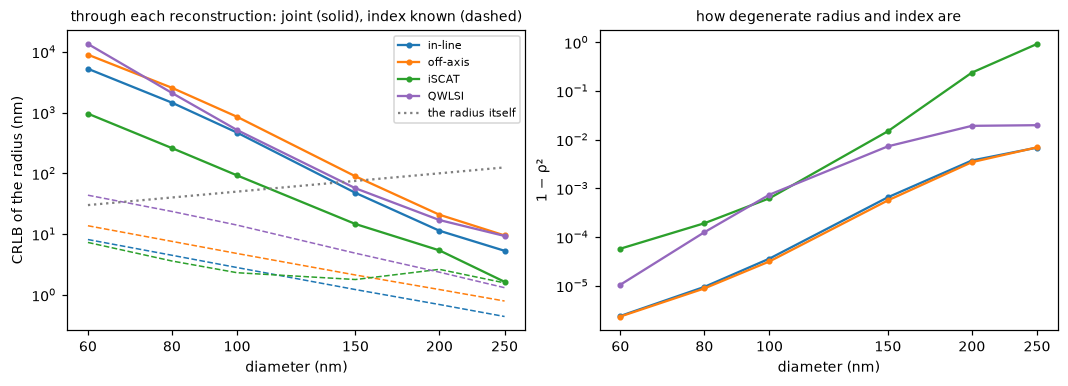

In [3]:
diameters = [0.06, 0.15] if SMOKE else [0.06, 0.08, 0.1, 0.15, 0.2, 0.25]
table = {kind: [] for kind in KINDS}
start = time.perf_counter()
for d in diameters:
    for kind in KINDS:
        chain = microscope(kind, plane_wave(kind), beads(d, on_glass=kind == "iSCAT"))
        pipe = gx.Pipeline(chain, outputs=("expected",))
        table[kind].append(
            summary(gx.crlb(pipe, chain, wrt=WRT, reconstruction=reconstruction(kind, chain)))
        )
print(f"{len(diameters) * len(KINDS)} bounds in {time.perf_counter() - start:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4), layout="constrained")
size = 1e3 * np.array(diameters)
for kind in KINDS:
    joint = [row["radius"] for row in table[kind]]
    alone = [row["radius alone"] for row in table[kind]]
    axes[0].loglog(size, 1e3 * np.array(joint), "-o", color=COLORS[kind], label=kind, ms=3)
    axes[0].loglog(size, 1e3 * np.array(alone), "--", color=COLORS[kind], lw=1)
    axes[1].loglog(size, [row["1-rho2"] for row in table[kind]], "-o", color=COLORS[kind], ms=3)
axes[0].loglog(size, 1e3 * size / 2e3, ":", color="0.5", label="the radius itself")
axes[0].set(
    xlabel="diameter (nm)",
    ylabel="CRLB of the radius (nm)",
    title="through each reconstruction: joint (solid), index known (dashed)",
)
axes[0].legend(fontsize=7)
axes[1].set(xlabel="diameter (nm)", ylabel="1 − ρ²", title="how degenerate radius and index are")
for ax in axes:
    ax.set_xticks(size, [f"{s:.0f}" for s in size])
    ax.minorticks_off()
plt.show()
shown = diameters.index(0.1) if 0.1 in diameters else 0
for kind in KINDS:
    row = table[kind][shown]
    print(
        f"{kind:9s} {1e3 * diameters[shown]:.0f} nm bead: σ_r = {1e3 * row['radius']:8.2f} nm"
        f" jointly, {1e3 * row['radius alone']:6.3f} nm with the index known;"
        f" σ_n = {row['index']:.3g}"
    )

Below about 150 nm, 1 − ρ² falls under 10⁻², reaching 10⁻⁶–10⁻⁴ at 60 nm. The data constrain one
combination of radius and index (close to the polarisability) almost perfectly, and the
orthogonal combination hardly at all. The joint bound on the radius exceeds the radius itself
below about 115 nm in iSCAT and 160 nm in transmission; with the index known, the radius is
bounded to a few nanometres. The microscopes differ
by orders of magnitude at the same dose: iSCAT collects the backscatter at NA 1.4 against a
reference that adds little shot noise, and each reconstruction keeps a different share of the
frames' information (Ex10, §5).

## 3. The reference: contrast is not information

iSCAT experiments often attenuate the reference with a pupil filter to raise the particles'
contrast (`gx.presets.ISCAT(attenuation=t)`, a disc of 10 % of the NA in the pupil). The bound
on the radius (index known) at two doses tells what that buys.

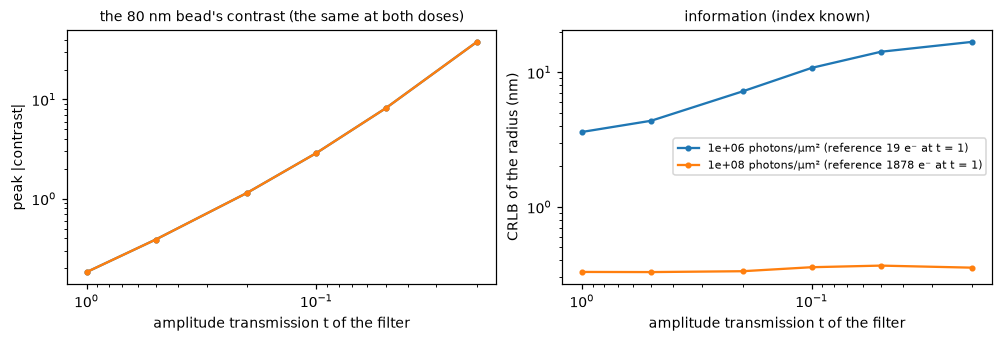

In [4]:
transmissions = [1.0, 0.1] if SMOKE else [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
curves = {}
for dose in (1e6, 1e8):
    rows = []
    for t in transmissions:
        scope = gx.presets.ISCAT(
            light=plane_wave("iSCAT", dose=dose),
            objective=gx.Objective(NA=1.4, magnification=MAG),
            camera=camera,
            attenuation=None if t == 1.0 else tensor(t),
            filter_radius=0.14,
        )
        sample = gx.Sample({"beads": beads(0.08, on_glass=True)}, environment=GLASS)
        plan = gx.plan(sample, scope, "standard", outputs=("expected",))
        chain = plan.chain(sample, scope)
        bound = gx.crlb(plan.pipeline, chain, wrt="beads.radius")
        frame = chain(outputs=("expected",)).expected
        reference = gx.recon.without_scatterers(chain)(outputs=("expected",)).expected
        rows.append(
            (
                float((frame / reference - 1).abs().max()),
                float(reference.mean()),
                1e3 * float(bound["beads.radius"].reshape(-1)[0]),
            )
        )
    curves[dose] = np.array(rows)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.0), layout="constrained")
for dose, rows in curves.items():
    axes[0].loglog(transmissions, rows[:, 0], "-o", ms=3, label=f"{dose:.0e} photons/µm²")
    axes[1].loglog(
        transmissions,
        rows[:, 2],
        "-o",
        ms=3,
        label=f"{dose:.0e} photons/µm² (reference {rows[0, 1]:.0f} e⁻ at t = 1)",
    )
axes[0].set(
    xlabel="amplitude transmission t of the filter",
    ylabel="peak |contrast|",
    title="the 80 nm bead's contrast (the same at both doses)",
)
axes[1].set(
    xlabel="amplitude transmission t of the filter",
    ylabel="CRLB of the radius (nm)",
    title="information (index known)",
)
axes[1].legend(fontsize=7)
for ax in axes:
    ax.invert_xaxis()
plt.show()

Attenuating the reference raises the contrast as 1/t, but the information stays put as long as
the attenuated reference outshines the read noise: in the shot-noise limit the interference term
and its noise scale together. When the reference sinks to a few electrons (the low dose), the
bound degrades. Attenuation pays when the camera's full well, not the sample, limits the light:
it lets the illumination rise by 1/t² at constant counts per pixel.

## 4. A pupil modulator that focuses onto the bead

A phase-only spatial light modulator in the illumination pupil (`gx.devices.PhaseSLM` read by
`gx.light.Shaped`) turns each of its Q×Q pixels into a plane wave, all mutually coherent, at the
same total power as the plane wave. Optimised for one bead at a known position, it learns to
focus the light onto it: the bound improves because the bead sees more light, not because each
scattered photon says more. The figure checks the design at other positions, and compares a
design trained on a dozen random positions.

two pupil designs in 18 s


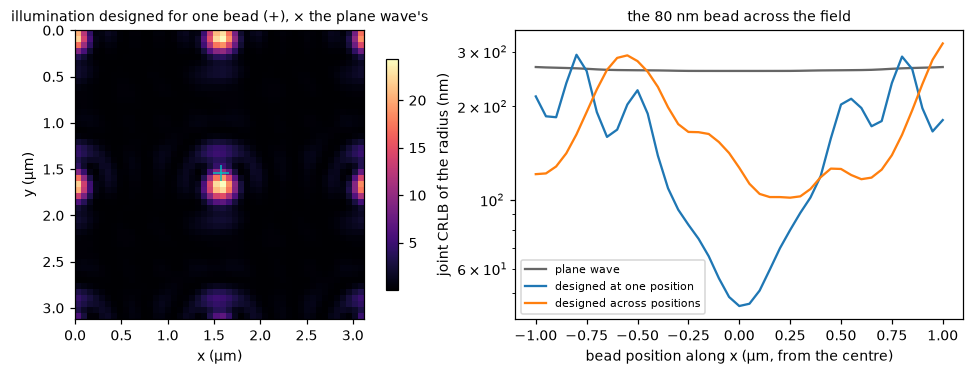

In [5]:
Q = 6  # SLM pixels per axis: 36 plane waves
d_small = 0.08
flat_phase = torch.zeros(Q, Q, dtype=F64, device=DEVICE)
slm_template = gx.light.Shaped(
    tensor(WAVELENGTH),
    na=1.0,
    travel=-1,
    irradiance=tensor(DOSE),
    device=gx.devices.PhaseSLM(phase=flat_phase),
)
generator = torch.Generator().manual_seed(0)


def slm_light(phase: torch.Tensor) -> gx.light.Shaped:
    """Return the shaped epi illumination for a pupil phase [Q, Q]."""
    return slm_template.replace(device=gx.devices.PhaseSLM(phase=phase))


def random_positions(count: int, half_width: float = 1.0) -> torch.Tensor:
    """Return count random bead positions [count, 2] in the central 2·half_width µm square."""
    offsets = (torch.rand(count, 2, generator=generator, dtype=F64) - 0.5) * 2 * half_width
    return (centre + offsets).to(DEVICE)


slm_pipes: dict[int, gx.Pipeline] = {}


def slm_bound(phase: torch.Tensor, xy: torch.Tensor) -> gx.CRLB:
    """Return the bound for beads at xy [B, 2] under the pupil phase (iSCAT keeps everything)."""
    chain = microscope("iSCAT", slm_light(phase), beads(d_small, xy, on_glass=True))
    if xy.shape[0] not in slm_pipes:
        slm_pipes[xy.shape[0]] = gx.Pipeline(chain, outputs=("expected",))
    return gx.crlb(slm_pipes[xy.shape[0]], chain, wrt=WRT)


def log_loss(bound: gx.CRLB) -> torch.Tensor:
    """Return the mean over images of log σ_r + log σ_n: the joint bound's size."""
    return (torch.log(bound["beads.radius"]) + torch.log(bound["beads.material"])).mean()


def design_pupil(xy: torch.Tensor) -> torch.Tensor:
    """Optimise the pupil phase for beads at xy [B, 2] (mean log-loss over them)."""
    phase = (torch.rand(Q, Q, generator=generator, dtype=F64) * 6).to(DEVICE).requires_grad_()
    optimiser = torch.optim.Adam([phase], lr=0.2)
    for _ in range(STEPS):
        optimiser.zero_grad()
        log_loss(slm_bound(phase, xy)).backward()
        optimiser.step()
    return phase.detach()


start = time.perf_counter()
known = tensor([[centre + 0.013, centre - 0.021]])
at_one = design_pupil(known)
across = design_pupil(random_positions(4 if SMOKE else 12))
print(f"two pupil designs in {time.perf_counter() - start:.0f} s")

line = torch.stack(
    [
        torch.linspace(centre - 1.0, centre + 1.0, 5 if SMOKE else 41, dtype=F64),
        torch.full((5 if SMOKE else 41,), centre - 0.021, dtype=F64),
    ],
    -1,
).to(DEVICE)
flat = microscope("iSCAT", plane_wave("iSCAT"), beads(d_small, line, on_glass=True))
reference_bound = gx.crlb(gx.Pipeline(flat, outputs=("expected",)), flat, wrt=WRT)
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.3), layout="constrained")
pixels = torch.arange(N, dtype=F64, device=DEVICE) + 0.5
yy, xx = torch.meshgrid(pixels * pitch, pixels * pitch, indexing="ij")
points = torch.stack([xx, yy, torch.zeros_like(xx)], -1).reshape(1, 1, -1, 3)
waves = slm_light(at_one)(GLASS)
intensity = (waves.at(points, 1.52).abs() ** 2).reshape(N, N) / DOSE
shown = axes[0].imshow(to_numpy(intensity), cmap="magma", extent=(0, N * pitch, N * pitch, 0))
axes[0].plot(float(known[0, 0]), float(known[0, 1]), "c+", ms=10)
axes[0].set(
    title="illumination designed for one bead (+), × the plane wave's",
    xlabel="x (µm)",
    ylabel="y (µm)",
)
fig.colorbar(shown, ax=axes[0], shrink=0.8)
x_axis = to_numpy(line[:, 0] - centre)
plane = to_numpy(1e3 * reference_bound["beads.radius"].reshape(-1))
axes[1].semilogy(x_axis, plane, color="0.4", label="plane wave")
for phase, label in ((at_one, "designed at one position"), (across, "designed across positions")):
    axes[1].semilogy(
        x_axis, to_numpy(1e3 * slm_bound(phase, line)["beads.radius"].reshape(-1)), label=label
    )
axes[1].set(
    xlabel="bead position along x (µm, from the centre)",
    ylabel="joint CRLB of the radius (nm)",
    title=f"the {1e3 * d_small:.0f} nm bead across the field",
)
axes[1].legend(fontsize=7)
plt.show()

Designed for one position, the modulator concentrates the light into a grid of foci (the pupil's
6×6 samples make the pattern periodic), and the bead at the design position gains several-fold. The
gain fades as the bead moves off the focus, and between foci the bound is worse than the plane
wave's. Designed across positions, the gain shrinks to what survives averaging, and it still varies
with position: coherent waves always interfere, so a pupil modulator's illumination has fringes.

## 5. Uniform illumination at a designed angle

A uniform field needs a single plane wave, whose direction a modulator in a field plane sets
(a blazed grating tilts the whole beam). Its information is the same at every position in the
field, by translation invariance. The design variable is the direction u, kept inside a disc
through a smooth map. For iSCAT the light comes through the objective (|u| < 1.4); for off-axis
holography it may pass the detection NA (0.8), which is darkfield: the unscattered light then
misses the camera and only the reference interferes with the scattered field. The off-axis design
is judged through its reconstruction.

In [6]:
LIMIT = {"iSCAT": 1.38, "off-axis": 1.25}  # |u| inside the objective, or the water
angle_pipes: dict[str, gx.Pipeline] = {}


def direction(w: torch.Tensor, kind: str) -> torch.Tensor:
    """Map free parameters w [2] to a direction u [2] with |u| < LIMIT[kind]."""
    norm = torch.sqrt((w * w).sum() + 1e-12)
    return LIMIT[kind] * torch.tanh(norm) * w / norm


def angle_bound(kind: str, u: torch.Tensor, share: float = 1.0) -> gx.CRLB:
    """Return the bound through the reconstruction for a plane wave of direction u (and dose)."""
    bead = beads(d_small, on_glass=kind == "iSCAT")
    chain = microscope(kind, plane_wave(kind, u, DOSE * share), bead, dose=DOSE * share)
    if kind not in angle_pipes:
        angle_pipes[kind] = gx.Pipeline(chain, outputs=("expected",))
    calibration = microscope(
        kind, plane_wave(kind, u.detach(), DOSE * share), bead, dose=DOSE * share
    )
    recon = None if kind == "iSCAT" else reconstruction(kind, calibration)  # iSCAT keeps all
    return gx.crlb(angle_pipes[kind], chain, wrt=WRT, reconstruction=recon, tolerance=1e-6)


def design_angles(kind: str, states: int, seed: int) -> list[torch.Tensor]:
    """Optimise `states` alternating directions, each state with 1/states of the dose."""
    g = torch.Generator().manual_seed(seed)
    ws = [
        (torch.randn(2, generator=g, dtype=F64) * 0.4).to(DEVICE).requires_grad_()
        for _ in range(states)
    ]
    optimiser = torch.optim.Adam(ws, lr=0.05)
    for _ in range(STEPS):
        total = together([angle_bound(kind, direction(w, kind), 1.0 / states) for w in ws])
        optimiser.zero_grad()
        log_loss(total).backward()
        optimiser.step()
    return [direction(w.detach(), kind) for w in ws]


start = time.perf_counter()
normal = {kind: summary(angle_bound(kind, tensor([0.0, 0.0]))) for kind in ("iSCAT", "off-axis")}
single = {kind: design_angles(kind, 1, seed=1) for kind in ("iSCAT", "off-axis")}
designed = {kind: summary(angle_bound(kind, single[kind][0])) for kind in single}
print(f"angle designs in {time.perf_counter() - start:.0f} s")
for kind in ("iSCAT", "off-axis"):
    u = single[kind][0]
    print(
        f"{kind:9s} normal incidence: σ_r = {1e3 * normal[kind]['radius']:9.2f} nm, "
        f"σ_n = {normal[kind]['index']:.3g}"
    )
    gain = normal[kind]["radius"] / designed[kind]["radius"]
    print(
        f"{'':9s} designed |u| = {float(u.norm()):.3f}:  σ_r = "
        f"{1e3 * designed[kind]['radius']:9.2f} nm, σ_n = {designed[kind]['index']:.3g}"
        f"  ({gain:.1f}× better)"
    )

angle designs in 27 s
iSCAT     normal incidence: σ_r =    260.03 nm, σ_n = 4.79
          designed |u| = 1.356:  σ_r =     57.12 nm, σ_n = 1.11  (4.6× better)
off-axis  normal incidence: σ_r =   2554.54 nm, σ_n = 51.1
          designed |u| = 1.132:  σ_r =    553.24 nm, σ_n = 10.9  (4.6× better)


The optimiser finds two known techniques:

- **iSCAT** chooses total internal reflection, just past the critical angle (|u| slightly above
  n_water = 1.33). The reflection becomes total, the reference far stronger than the read noise,
  and the evanescent field at the glass is enhanced near the critical angle. That field decays
  away from the coverslip within ~0.2 µm, so the gain holds for beads on the glass.
- **Off-axis holography** chooses darkfield illumination: the unscattered light, and its shot
  noise, no longer reach the camera, and the scattered field meets only the reference.

## 6. Two alternating states

A modulator can alternate between two states, each frame read out on its own. Independent
frames add their information, so the bound of the pair is `bound_a + bound_b`. The design
optimises both directions together, each state getting half the dose, so the comparison with a
single state is at equal photons.

pair designs in 55 s
iSCAT     the pair's σ_r is 50.63 nm against 57.12 nm for one state (+13%)
off-axis  the pair's σ_r is 422.12 nm against 553.24 nm for one state (+31%)


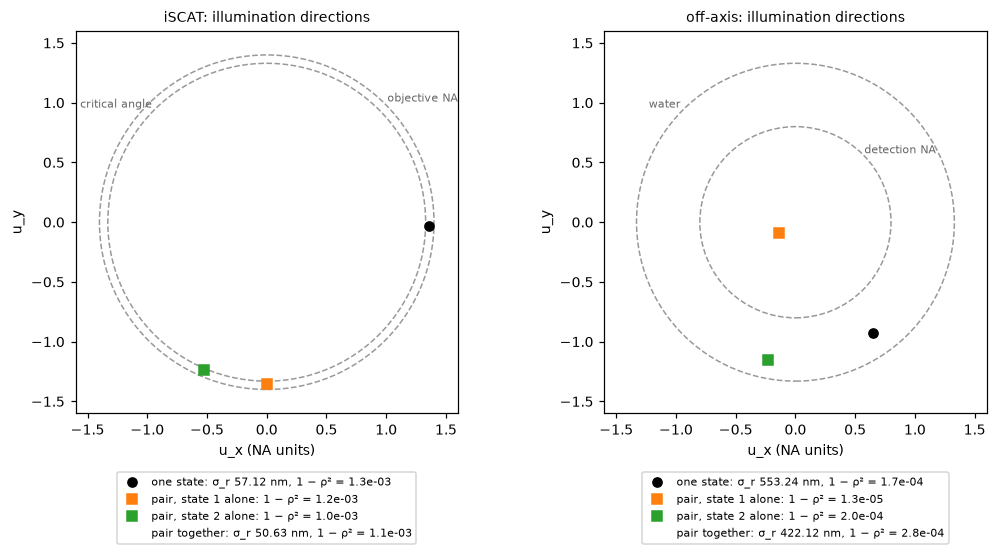

In [7]:
start = time.perf_counter()
pairs = {kind: design_angles(kind, 2, seed=2) for kind in ("iSCAT", "off-axis")}
print(f"pair designs in {time.perf_counter() - start:.0f} s")
fig, axes = plt.subplots(1, 2, figsize=(9.6, 5.0), layout="constrained")
for ax, kind in zip(axes, ("iSCAT", "off-axis"), strict=True):
    states = [angle_bound(kind, u, 0.5) for u in pairs[kind]]
    both = summary(states[0] + states[1])  # alternating readouts: bound_a + bound_b
    each = [summary(s) for s in states]
    circles = {
        "iSCAT": [(1.4, "objective NA", 45), (1.33, "critical angle", 135)],
        "off-axis": [(0.8, "detection NA", 45), (1.33, "water", 135)],
    }[kind]
    for radius, label, at in circles:
        ax.add_patch(plt.Circle((0, 0), radius, fill=False, ls="--", color="0.6"))
        angle = math.radians(at)
        ax.text(
            1.02 * radius * math.cos(angle),
            1.02 * radius * math.sin(angle),
            label,
            fontsize=7,
            color="0.4",
            ha="left" if at < 90 else "right",
        )
    u1 = single[kind][0]
    ax.plot(
        *to_numpy(u1),
        "ko",
        label=f"one state: σ_r {1e3 * designed[kind]['radius']:.2f} nm, "
        f"1 − ρ² = {designed[kind]['1-rho2']:.1e}",
    )
    for i, u in enumerate(pairs[kind]):
        ax.plot(
            *to_numpy(u),
            "s",
            color=f"C{i + 1}",
            label=f"pair, state {i + 1} alone: 1 − ρ² = {each[i]['1-rho2']:.1e}",
        )
    ax.plot(
        [],
        [],
        " ",
        label=f"pair together: σ_r {1e3 * both['radius']:.2f} nm, 1 − ρ² = {both['1-rho2']:.1e}",
    )
    ax.set(
        xlim=(-1.6, 1.6),
        ylim=(-1.6, 1.6),
        aspect="equal",
        xlabel="u_x (NA units)",
        ylabel="u_y",
        title=f"{kind}: illumination directions",
    )
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.14))
    print(
        f"{kind:9s} the pair's σ_r is {1e3 * both['radius']:.2f} nm against "
        f"{1e3 * designed[kind]['radius']:.2f} nm for one state "
        f"({designed[kind]['radius'] / both['radius'] - 1:+.0%})"
    )
plt.show()

The pair improves on the single state in both microscopes, at the same number of photons:

- **Off-axis holography** gains the most by pairing a brightfield direction with a darkfield
  one. Each state's information is degenerate along a different combination of radius and
  index, so the pair's 1 − ρ² exceeds either state's.
- **iSCAT** keeps total internal reflection in both states, at different azimuths.

Both results hold anywhere in the field of view, since the illumination is uniform. A pupil
modulator could not give that guarantee.

**Caveats.** The scattering model is scalar (P = 1): total internal reflection and darkfield are
where polarisation matters most, so these numbers compare designs and do not yet predict an
experiment (the vector model, P = 2, is M3a's phase 6). The bound is local: it assumes the
estimator starts near the truth and knows the reference and background. The modulator is
ideal (no pixel crosstalk, no quantisation), and the grating and filters transmit their nominal
power (issue #8).

**Where next.** §5.12 and ADR-44 of the architecture document; Ex9 for pupil design by the same
machinery; `gx.recon` for the reconstructions.